# Elliptic problems: rectangle separation

We use Laplace’s equation on a rectangle with zero data on three sides and a polynomial top boundary. This family is deliberately shown through both the generic planner and the geometry-specific direct API.

**Tutorial contract.** This notebook derives the mathematics, asks PDESolve how it recognizes/plans the problem, executes the solver, independently checks the returned mathematics where appropriate, visualizes the solution or its structure, and ends with runnable variations plus exercises.

In [1]:
from pathlib import Path
import sys

# Make a source checkout importable without requiring an editable install.
root = Path.cwd().resolve()
for candidate in [root, *root.parents]:
    if (candidate / "pdesolve").is_dir():
        ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the pdesolve source tree")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pdesolve as pds
from IPython.display import display

sp.init_printing()
print("PDESolve source:", ROOT)
print("SymPy:", sp.__version__)

PDESolve source: /mnt/data/pdesolve_doc22SymPy: 1.14.0

In [2]:
def show_plan(problem, n=6):
    """Display recognizer output and the highest-ranked canonical plan steps."""
    rec = pds.recognize_canonical_problem(problem)
    plan = pds.plan_canonical_problem(problem)
    print("Recognition:", rec)
    print("Top plan steps:")
    for step in plan.steps[:n]:
        print(f"  {step.method:42s} score={step.score}")
    return rec, plan


def rhs_of(solution):
    """Extract the RHS of an Eq result, or return an expression unchanged."""
    return solution.rhs if isinstance(solution, sp.Equality) else solution


def residual(eq, dependent, candidate):
    """Classical residual after replacing the dependent function by candidate."""
    expr = eq.lhs - eq.rhs if isinstance(eq, sp.Equality) else eq
    return sp.simplify(expr.subs(dependent, candidate).doit())

## 1. Separation DerivationFor $u_{xx}+u_{yy}=0$ on $0<x<\pi$, $0<y<\pi$, zero data at $x=0$, $x=\pi$, and $y=0$ select$$u(x,y)=\sum_{n\ge1} b_n\frac{\sinh(ny)}{\sinh(n\pi)}\sin(nx),$$where $b_n$ are the sine coefficients of the top trace $g(x)=x(\pi-x)$.

In [3]:
x, y = sp.symbols("x y", real=True)
u = sp.Function("u")
eq = sp.Eq(sp.diff(u(x,y),x,2)+sp.diff(u(x,y),y,2),0)
problem = pds.build_pde_problem(eq, u(x,y), (x,y))
recognition, plan = show_plan(problem)

Recognition: (PDERecognitionRecord(family='wave_like', recognized=True, solver_hint='wave_dalembert', tags=('dAlembert', 'separation_of_variables'), metadata={}),)Top plan steps:  constant_coefficient_inverse_operator      score=92  structured_transform                       score=77  wave_dalembert                             score=70  symmetry_reduction                         score=60  post_reduction_auto                        score=48  classification_only                        score=20

PDEIVPResult laplace_rectangle_dirichlet_series

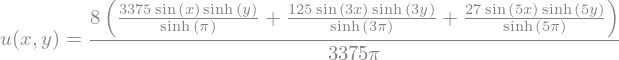

In [4]:
from pdesolve.classical import solve_rectangle_dirichlet_laplace_series
result = solve_rectangle_dirichlet_laplace_series(u(x,y), x=x, y=y, boundary_top=x*(sp.pi-x), terms=5)
print(type(result).__name__, result.method)
display(result.solution)

In [5]:
sol = rhs_of(result.solution)
print("Laplace residual:", sp.simplify(sp.diff(sol,x,2)+sp.diff(sol,y,2)))
print("Bottom boundary:", sp.simplify(sol.subs(y,0)))
print("Left boundary:", sp.simplify(sol.subs(x,0)))
print("Right boundary:", sp.simplify(sol.subs(x,sp.pi)))
assert sp.simplify(sp.diff(sol,x,2)+sp.diff(sol,y,2)) == 0

Laplace residual: 0Bottom boundary: 0Left boundary: 0Right boundary: 0

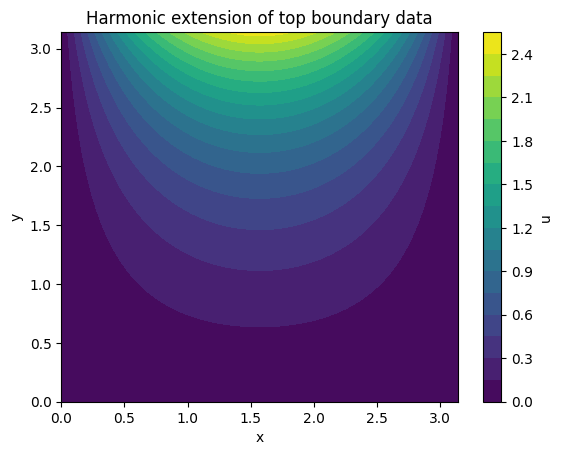

In [6]:
f = sp.lambdify((x,y),sol,"numpy")
xx=np.linspace(0,float(sp.pi),160); yy=np.linspace(0,float(sp.pi),120); X,Y=np.meshgrid(xx,yy); Z=f(X,Y)
fig, ax=plt.subplots(); cs=ax.contourf(X,Y,Z,levels=20); fig.colorbar(cs,ax=ax,label="u")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title("Harmonic extension of top boundary data"); plt.show()

## 3. Variation and exercisesIncrease the number of modes. Then: (1) compare the top-boundary approximation with $x(\pi-x)$; (2) explain why convergence near corners can be slower when boundary traces are incompatible; (3) inspect the capability matrix for disk/annulus limitations.

laplace_rectangle_dirichlet_series

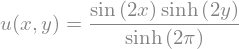

In [7]:
r2 = solve_rectangle_dirichlet_laplace_series(u(x,y), x=x, y=y, boundary_top=sp.sin(2*x), terms=5)
print(r2.method); display(r2.solution)